In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)

In [2]:
music_streams = pd.read_csv("D:/carrie works/SFU_Prepare/882/Data/music_streams.csv")

In [3]:
music_streams.head(5)

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [4]:
music_streams.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [5]:
music_streams.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram

<function matplotlib.pyplot.show(close=None, block=None)>

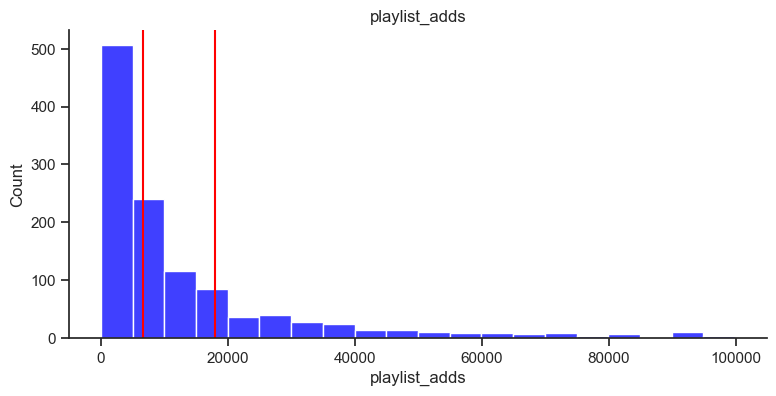

In [6]:
fig, ax =plt.subplots(figsize= (9,4))
median = music_streams.playlist_adds.median()
mean = music_streams.playlist_adds.mean()
sns.histplot(data= music_streams[music_streams.playlist_adds < 100000], x = "playlist_adds", ax= ax, bins= 20, color = "blue")
ax.axvline (median, color = "red", label = "median")
ax.axvline (mean, color = "red", label = "mean")
# ax.legend()
ax.set_xlabel('playlist_adds')
ax.set_title('playlist_adds')
plt.show

In [7]:
def create_hist(df, column):
    # df = music_streams
    fig, ax =plt.subplots(figsize= (9,4))
    median = df.column.median()
    mean = df.column.mean()
    data = df[df.column < 100]
    sns.histplot(data= df[df.column < 100], x = "streams_millions", ax= ax, bins= 20, color = "blue")
    ax.axvline (median, color = "red", label = "median")
    ax.axvline (mean, color = "red", label = "mean")
# ax.legend()
    ax.set_xlabel('MonthlyStream')
    ax.set_ylabel()

Text(0.5, 0, 'MonthlyStream')

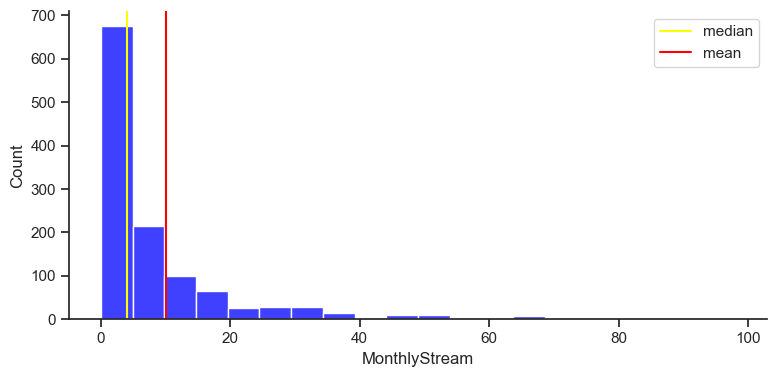

In [27]:
fig, ax =plt.subplots(figsize= (9,4))
median = music_streams.streams_millions.median()
mean = music_streams.streams_millions.mean()
sns.histplot(data= music_streams[music_streams.streams_millions < 100], x = "streams_millions", ax= ax, bins= 20, color = "blue")
ax.axvline (median, color = "yellow", label = "median")
ax.axvline (mean, color = "red", label = "mean")
ax.legend()
ax.set_xlabel('MonthlyStream')

## Boxplot

In [28]:
order = music_streams.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

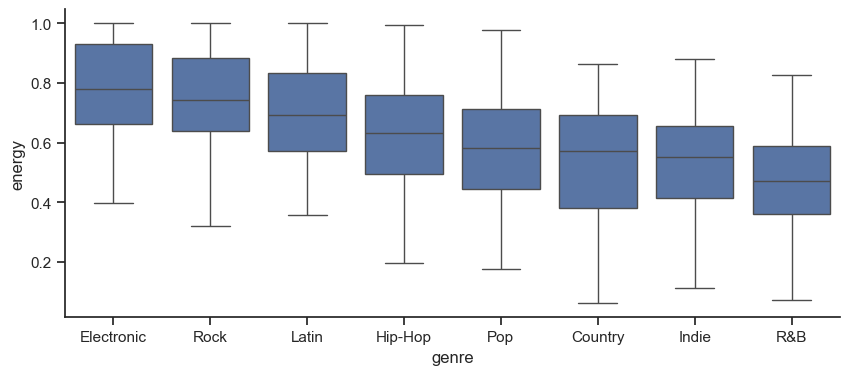

In [29]:
fig, ax = plt.subplots(figsize=[10,4])
sns.boxplot(data= music_streams , y="energy", x="genre", order=order, ax=ax)

In [11]:
order = music_streams.groupby("genre")["danceability"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Country', 'Pop', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='danceability'>

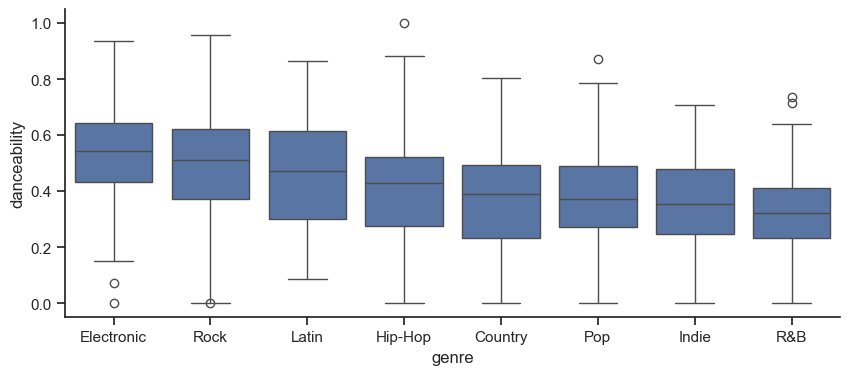

In [12]:
fig, ax = plt.subplots(figsize=[10,4])
sns.boxplot(data= music_streams , y="danceability", x="genre", order=order, ax=ax)

In [13]:
music_streams["monthly_listeners_log"] = np.log(music_streams["monthly_listeners"])

In [14]:
order = music_streams.groupby("genre")["monthly_listeners_log"].median().sort_values(ascending=False).index
order

Index(['Latin', 'Pop', 'Electronic', 'Country', 'Rock', 'Hip-Hop', 'R&B',
       'Indie'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='monthly_listeners_log'>

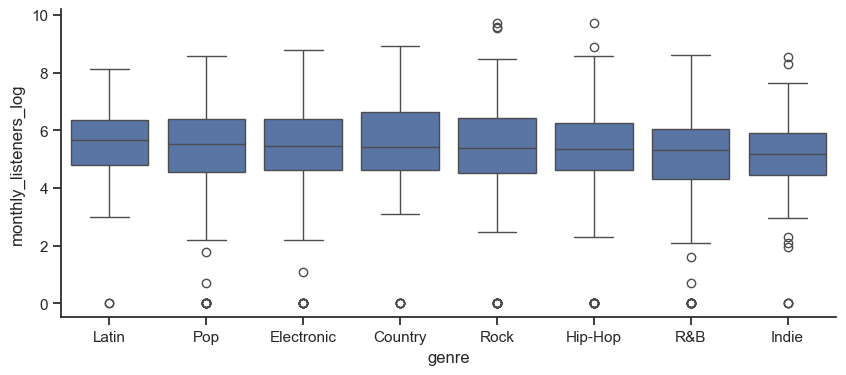

In [15]:
fig, ax = plt.subplots(figsize=[10,4])
sns.boxplot(data= music_streams , y="monthly_listeners_log", x="genre", order=order, ax=ax)

## Scatterplot

<Axes: xlabel='energy', ylabel='danceability'>

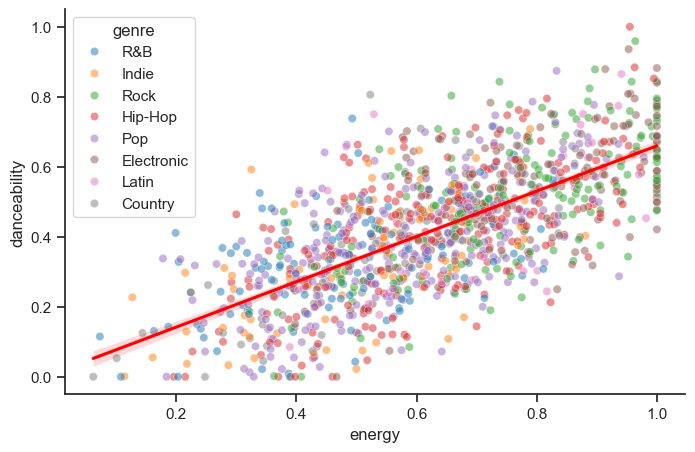

In [16]:
sample = music_streams.sample(600)
fig, ax = plt.subplots(figsize=[8,5])
sns.scatterplot(data = music_streams , x= "energy" , y = "danceability", hue ="genre", palette="tab10" ,ax= ax, color= "grey", alpha = 0.5)
sns.regplot(data = music_streams , x= "energy" , y = "danceability", ax = ax, scatter= False, color= "red")

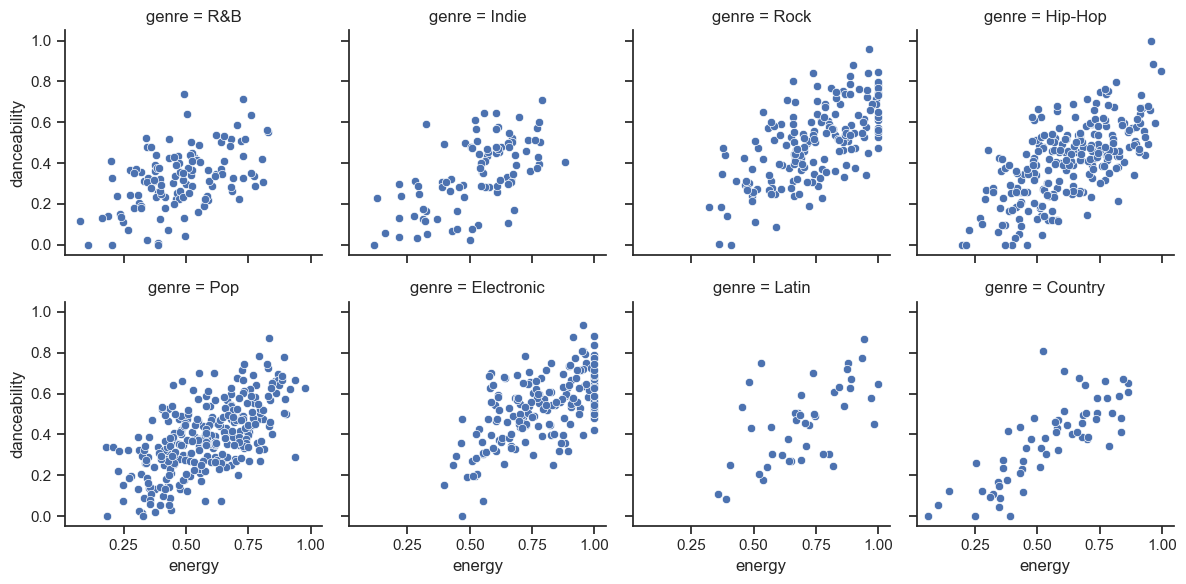

In [17]:
g= sns.FacetGrid(music_streams, col="genre", col_wrap =4)
g.map(sns.scatterplot, "energy", "danceability")

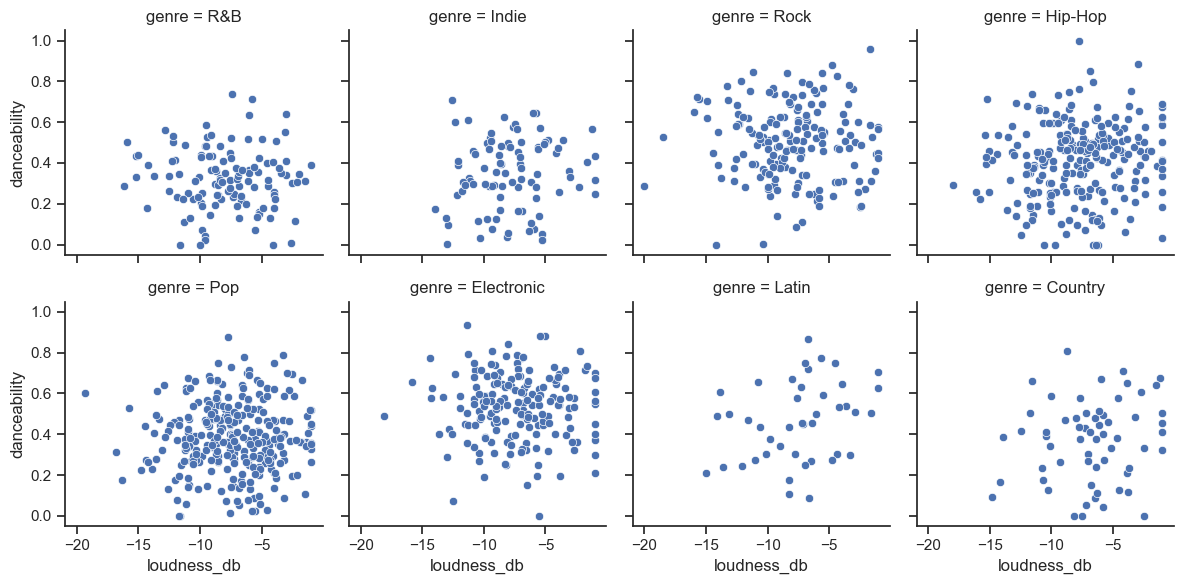

In [30]:
g= sns.FacetGrid(music_streams, col="genre", col_wrap =4)
g.map(sns.scatterplot, "loudness_db", "danceability")

line charts and friends

In [19]:
music_streams.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label,monthly_listeners_log
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL,5.170484
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds,5.135798
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans,6.646391
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music,0.000000
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds,0.000000


In [20]:
music_streams.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [21]:
music_streams.genre.unique()

array(['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin',
       'Country'], dtype=object)

In [22]:
genres = ['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic']

In [62]:
trend = music_streams[music_streams.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()



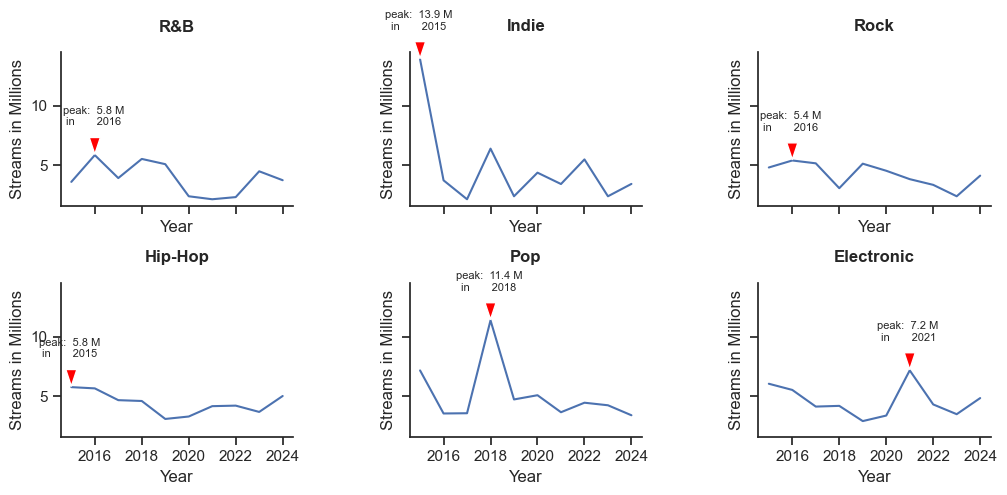

In [71]:
fig, axes = plt.subplots(2, 3, figsize=[12,5], sharex= True, sharey= True)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
axes= axes.flatten()
for ax, genre in zip(axes, genres):
    sub=trend[trend.genre == genre]
    peak = sub.loc[sub.streams_millions.idxmax()]
    ax.plot(sub.year, sub.streams_millions)
    ax.annotate(f"peak: {peak.streams_millions: .1f} M \nin {peak.year :>10} \n", xy = (peak.year,peak.streams_millions), xytext=[0,13], textcoords = "offset points", ha= "center", fontsize=8,  arrowprops=dict(
        facecolor='red',       
        shrink=0.06,            
        width=1.5,             
        headwidth=8              
    ))
    # ax.axhline(y=5, color='black',alpha = 0.5, linewidth=1)
    ax.set_xlabel('Year')
    ax.set_ylabel('Streams in Millions')
    ax.set_title(genre, fontweight= "bold", pad=15)
   

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=[12,5], sharex= True, sharey= True)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
axes= axes.flatten()
for ax, genre in zip(axes, genres):
    sub=trend[trend.genre == genre]
    peak = sub.loc[sub.streams_millions.idxmax()]
    ax.plot(sub.year, sub.streams_millions)
    ax.annotate(f"peak: {peak.streams_millions: .1f} M \nin {peak.year :>10} \n", xy = (peak.year,peak.streams_millions), xytext=[0,13], textcoords = "offset points", ha= "center", fontsize=8,  arrowprops=dict(
        facecolor='red',       
        shrink=0.06,            
        width=1.5,             
        headwidth=8              
    ))
    ax.set_xlabel('Year')
    ax.set_ylabel('Streams in Millions')
    ax.set_title(genre, fontweight= "bold", pad=15)

In [53]:
music_streams.label.unique()

array(['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope',
       'Jagjaguwar'], dtype=object)

In [78]:
labels = ['AWAL', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Jagjaguwar']

In [108]:
trend = music_streams[music_streams.label.isin(labels)].groupby(["year", "label"])["monthly_listeners"].median().reset_index()

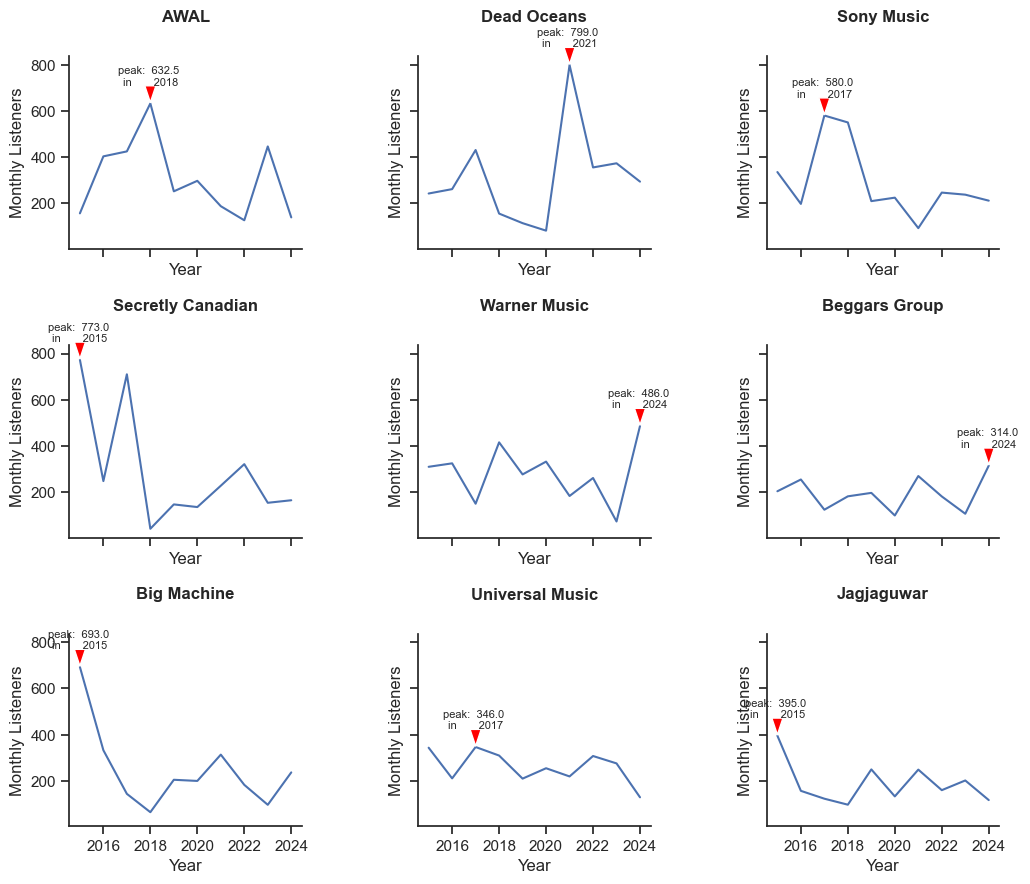

In [116]:
fig, axes = plt.subplots(3, 3, figsize=[12,10], sharex= True, sharey= True)
fig.subplots_adjust(wspace=0.5, hspace=0.5)
axes= axes.flatten()
for ax, label in zip(axes, labels):
    sub=trend[trend.label == label]
    peak = sub.loc[sub.monthly_listeners.idxmax()]
    ax.plot(sub.year, sub.monthly_listeners)
    ax.annotate(f"peak: {peak.monthly_listeners: .1f} \nin {peak.year :>10}", xy = (peak.year,peak.monthly_listeners), xytext=[0,13], textcoords = "offset points", ha= "center", fontsize=8,  arrowprops=dict(
        facecolor='red',       
        shrink=0.06,            
        width=1.5,             
        headwidth=8              
    ))
    ax.set_xlabel('Year')
    ax.set_ylabel('Monthly Listeners')
    ax.set_title(label, fontweight= "bold", pad=25)

## Vega-lite Altair examples

In [154]:
import altair as alt

In [155]:
sel = alt.selection_point(fields=['genre'], bind='legend')

alt.Chart(music_streams[music_streams.streams_millions < 150]).mark_bar(opacity=0.7).encode(
    x=alt.X('streams_millions:Q', bin=alt.Bin(maxbins=45), title='Streams (M)'),
    y=alt.Y('count():Q', title='Songs'),
    color=alt.Color('genre:N', scale=alt.Scale(scheme='tableau10'), title='Genre'),
    opacity=alt.condition(sel, alt.value(0.85), alt.value(0.08)),
    tooltip=['genre:N', 'count():Q',
             alt.Tooltip('streams_millions:Q', bin=alt.Bin(maxbins=45), title='Streams range (M)')]
).add_params(sel).properties(width=600, height=300)





alt.Chart(...)

In [156]:
alt.Chart(music_streams).mark_bar().encode(
    x="year:N",
    y="danceability:Q",
    xOffset="genre:N",
    color="genre:N",
     tooltip=['genre:N', 'count():Q']
)

alt.Chart(...)

In [157]:
sample = music_streams.sample(600)
hover = alt.selection_point(on='pointerover', nearest=True, empty=False)
when_hover = alt.when(hover)

chart = alt.Chart(sample, title='Selection brought to back').mark_circle(opacity=1).encode(
    y='danceability:Q',
    x='energy:Q',
    color=when_hover.then(alt.value("coral")).otherwise(alt.value("lightblue")),
    size=when_hover.then(alt.value(80)).otherwise(alt.value(30)),
    tooltip=[
        alt.Tooltip('title:N', title='Track'),
        alt.Tooltip('artist:N', title='Artist'),
        alt.Tooltip('genre:N', title='Genre'),
        alt.Tooltip('energy:Q', format='.2f'),
        alt.Tooltip('danceability:Q', format='.2f'),
        alt.Tooltip('streams_millions:Q', title='Streams (M)', format='.1f'),
    ]
).add_params(
    hover
)


chart | chart.encode(
    order=when_hover.then(alt.value(1)).otherwise(alt.value(0))
).properties(
    title='Selection brought to front'
)


alt.HConcatChart(...)